# Directional coupler (anisotropic TFLN)

## Parameters


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import luminescent as lm

# simulation folder
path = os.path.join("runs", "TFLN_coupler")

# length units are arbitrary so long as they're consistent
wavelength = 1.55
bandwidth = 0.1
nwls = 51
wavelengths = np.linspace(wavelength - bandwidth / 2, wavelength + bandwidth / 2, nwls)
boundaries = ["PML", "PML", "PML"]

# coupler dims
w_wg = 1
gap = 0.3
length = 5
dx = 30
dy = 15
margin = 1
source_offset = 2

# layer stack dims
h_rib = 0.4
h_slab = 0.2
sidewall_angle = 20
zmargin = 1
zmin = -h_slab - zmargin
zmax = h_rib + zmargin

# simulation parameters
nres = 6
stop_decay = 1e-3
tmax = 100
PML_decay = [0.001, 0.01, 0.1]
views = [lm.View("Hz", x=0, y="half", z=h_rib / 2)]
frame_every = 5

# anisotropic TFLN: X-cut along y
ne = 2.14
no = 2.21
materials = {
    "LN": lm.Material(epsilon=[[no**2, 0, 0], [0, ne**2, 0], [0, 0, no**2]]),
    "SiO2": lm.Material(epsilon=2.25),
}
background = "SiO2"

# layers
WG = 1, 0
BBOX = 2, 0
layer_stack = LayerStack(
    layers={
        "rib": LayerLevel(
            layer=LogicalLayer(layer=WG),
            thickness=h_rib,
            zmin=0,
            material="LN",
            mesh_order=0,
            sidewall_anglele=sidewall_angle,
        ),
        "slab": LayerLevel(
            layer=LogicalLayer(layer=BBOX),
            thickness=h_slab,
            zmin=-h_slab,
            material="LN",
            mesh_order=1,
        ),
    }
)

## Geometry

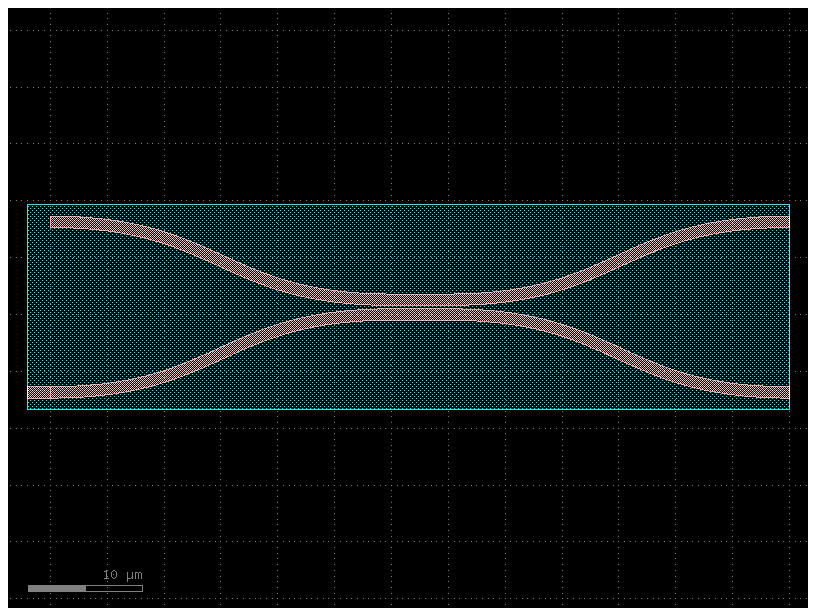

In [ ]:
# make component in gdsfactory. alternatively can import .gds into gdsfactory
c = gf.Component()

dut = c << gf.components.coupler(
    gap=gap,
    length=length,
    dx=dx,
    dy=dy,
    cross_section=gf.cross_section.cross_section(width=w_wg),
)
ext = c << gf.components.straight(length=source_offset, width=w_wg)
ext.connect("o2", dut.ports["o1"])

c << gf.components.bbox(component=c, layer=BBOX, top=margin, bottom=margin)

for p in dut.ports:
    c.add_port(p.name, port=p)

c.plot()

## Setup


(1564, 3)
(1564, 3)
(12, 3)
(12, 3)
origin: [-30.0, -6.8500000000000005, 0.0], frame: [[-1.2246467991473532e-16, -1.0, 0], [0, 0, 1], [-1.0, 1.2246467991473532e-16, 0]], start: [-1.5, -1.2], stop: [1.5, 1.4],
polyeps: [(<POLYGON ((-0.5 0.0009, -0.5 0.4, -0.498 0.4, 0.5 0.4, 0.5 0.399, 0.5 0, -0....>, 4.7825999999999995, 'rib'), (<POLYGON ((-0.5 0.4, 0.5 0.4, 0.5 0, -0.5 0, -0.5 0.4))>, 4.7825999999999995, 'rib'), (<POLYGON ((1.5 0, 1.5 -0.2, -1.5 -0.2, -1.5 0, 1.5 0))>, 4.7825999999999995, 'slab'), (<POLYGON ((1.5 -1.2, 1.5 1.4, -1.5 1.4, -1.5 -1.2, 1.5 -1.2))>, 2.25, '')]
showing modes for wavelength 1.55
mode Boundary conditions: 0000


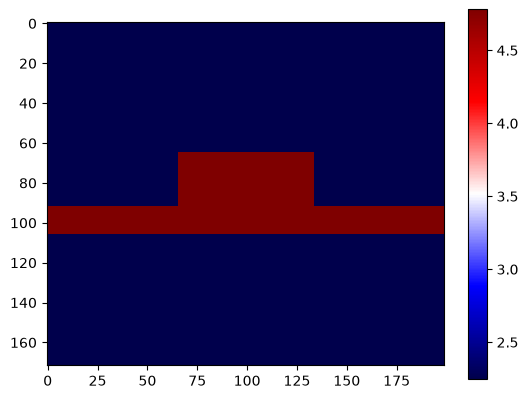

wg/1.55 mode 0 (neff=1.938+0.000j)
saving mode to /home/weihu/moon/luminescent/runs/TFLN_coupler/modes/wg/1.55/0.npz
using simulation folder /home/weihu/moon/luminescent/runs/TFLN_coupler


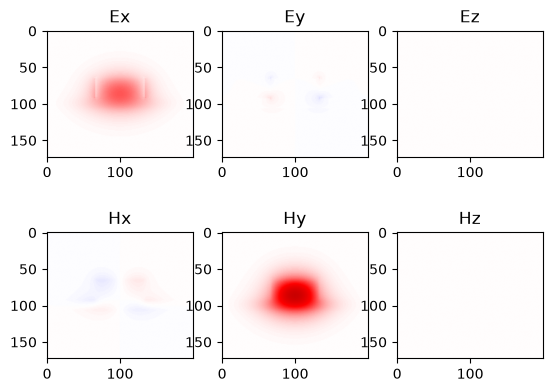

In [ ]:
bbox = c.bbox_np().tolist()
bbox[0].append(zmin)
bbox[1].append(zmax)

lx = w_wg + 2 * margin
sensors = [
    lm.Sensor(
        "wg",
        start=[-lx / 2, zmin],
        stop=[lx / 2, zmax],
        mode_solver_wavelengths=[wavelength],
    )
]
sources = [
    lm.Source(
        "o1_src",
        *lm.from_gf_port(c, "o1", source_offset),
        sensor="wg",
        wavelength=wavelength,
        bandwidth=wavelength / 5,
    )
]
monitors = [
    lm.Monitor("o1_mode", *lm.from_gf_port(c, "o1"), sensor="wg"),
    lm.Monitor("o3_mode", *lm.from_gf_port(c, "o3"), sensor="wg"),
    lm.Monitor("o4_mode", *lm.from_gf_port(c, "o4"), sensor="wg"),
]

lm.mesh(path, c, layer_stack, materials, zmin, zmax)
lm.setup(
    path=path,
    wavelength=wavelength,
    wavelengths=wavelengths,
    materials=materials,
    background=background,
    boundaries=boundaries,
    bbox=bbox,
    #
    sensors=sensors,
    sources=sources,
    monitors=monitors,
    #
    nres=nres,
    tmax=tmax,
    stop_decay=stop_decay,
    PML_decay=PML_decay,
    #
    views=views,
    frame_every=frame_every,
)

In [ ]:
lm.solve(path)

running Luminescent FDTD 2.0.0
IOError: open("runs/TFLN_coupler/.grid.json.tar", 0, 0): no such file or directory (ENOENT)
images and results saved in runs/TFLN_coupler


## Movie


In [ ]:
lm.movie(path)

## Results

loading solution from /home/weihu/lumi/luminescent/runs/TFLN_coupler
may take a minute if simulation folder is remotely mounted


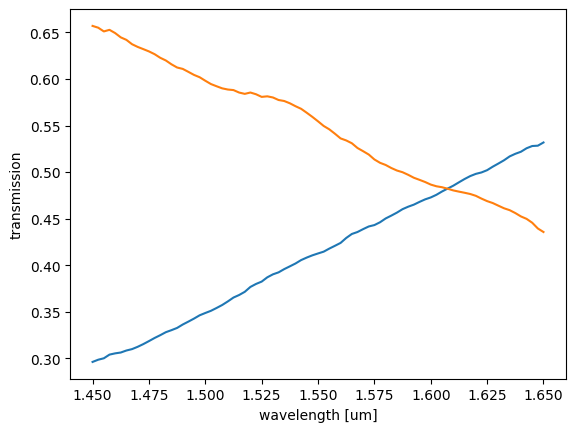

In [ ]:
sol = lm.load(path)
o1 = sol["monitors"]["o1_mode"]
o3 = sol["monitors"]["o3_mode"]
o4 = sol["monitors"]["o4_mode"]

# + denotes forward propagating mode (wrt port monitor normal)
S31 = o3["modes"][0]["+"] / o1["modes"][0]["-"]
S41 = o4["modes"][0]["+"] / o1["modes"][0]["-"]

plt.plot(wavelengths, np.abs(S31) ** 2, label="S31")
plt.plot(wavelengths, np.abs(S41) ** 2, label="S41")
plt.xlabel("wavelength [um]")
plt.ylabel("power")
plt.legend()
plt.show()